In [ ]:
import warnings

warnings.filterwarnings(action='ignore')

In [ ]:
!pip install sklearn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for sklearn: filename=sklearn-0.0.post5-py3-none-any.whl size=2950 sha256=4c9744f39e985e9dc304b3bf0a84adf2707a07b1c5ba047ce693cae4d99bc015
  Stored in directory: /root/.cache/pip/wheels/38/1f/8d/4f812c590e074c1e928f5cec67bf5053b71f38e2648739403a
Successfully built sklearn


In [ ]:
import numpy as np
import pandas as pd

bike_df = pd.read_csv('SeoulBikeData3.csv', sep = ',', header = 0, engine = 'python')
#bike_df = pd.read_csv('boston.csv', sep = ',', header = 0, index_col = 0, engine = 'python')

In [ ]:
bike_df.head()

,Date,RentedBikeCount,Hour,Temperature,Humidity,Windspeed,DewTemperature,SolarRadiation,Rainfall,Snowfall,Seasons,Holiday,FunctioningDay
0,01/12/2017,254,0,-5.2,37,2.2,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
bike_df.shape

(8760, 13)

In [ ]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             8760 non-null   object 
 1   RentedBikeCount  8760 non-null   int64  
 2   Hour             8760 non-null   int64  
 3   Temperature      8760 non-null   float64
 4   Humidity         8760 non-null   int64  
 5   Windspeed        8760 non-null   float64
 6   DewTemperature   8760 non-null   float64
 7   SolarRadiation   8760 non-null   float64
 8   Rainfall         8760 non-null   float64
 9   Snowfall         8760 non-null   float64
 10  Seasons          8760 non-null   object 
 11  Holiday          8760 non-null   object 
 12  FunctioningDay   8760 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 889.8+ KB


In [ ]:
bike_df.describe()

,RentedBikeCount,Hour,Temperature,Humidity,Windspeed,DewTemperature,SolarRadiation,Rainfall,Snowfall
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,27.200000,3.520000,35.000000,8.800000


In [27]:
bike_df = bike_df.drop(['Date', 'Seasons', 'Holiday', 'FunctioningDay', 'Hour'], axis = 1, inplace = False)
bike_df.head()

,RentedBikeCount,Temperature,Humidity,Windspeed,DewTemperature,SolarRadiation,Rainfall,Snowfall
0,254,-5.2,37,2.2,-17.6,0.0,0.0,0.0
1,204,-5.5,38,0.8,-17.6,0.0,0.0,0.0
2,173,-6.0,39,1.0,-17.7,0.0,0.0,0.0
3,107,-6.2,40,0.9,-17.6,0.0,0.0,0.0
4,78,-6.0,36,2.3,-18.6,0.0,0.0,0.0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [44]:
#X, Y 분할
Y = bike_df['RentedBikeCount']
X = bike_df.drop(['RentedBikeCount'], axis = 1, inplace = False)

In [45]:
#훈련용 데이터와 평가용 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 156)

In [46]:
lr = LinearRegression()

In [47]:
#선형 회귀 분석 : 모델 훈련
lr.fit(X_train, Y_train)

LinearRegression()

In [41]:
sample_predict = lr.predict([[-5.2, 37, 2.2, -17.6, 0, 0, 0]])
print(sample_predict)

[374.17988848]


In [ ]:
Y_predict = lr.predict(X_test)
print(Y_predict)

In [43]:
mse = mean_squared_error(Y_test, Y_predict)
rmse = np.sqrt(mse)

print('MSE :  {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('R^2(Variance score) : {0:.3f}'.format(r2_score(Y_test, Y_predict)))

MSE :  261109.095, RMSE : 510.988
R^2(Variance score) : 0.410


In [35]:
print('Y 절편 값 : ', lr.intercept_)
print('회귀 계수 값 : ', np.round(lr.coef_, 1))

Y 절편 값 :  763.9331902151848
회귀 계수 값 :  [  36.7   -9.6   56.6   -1.9 -113.8  -50.8   39. ]


In [36]:
coef = pd.Series(data = np.round(lr.coef_, 2), index = X.columns)
coef.sort_values(ascending = False)

Windspeed          56.62
Snowfall           38.99
Temperature        36.70
DewTemperature     -1.89
Humidity           -9.64
Rainfall          -50.78
SolarRadiation   -113.75
dtype: float64

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

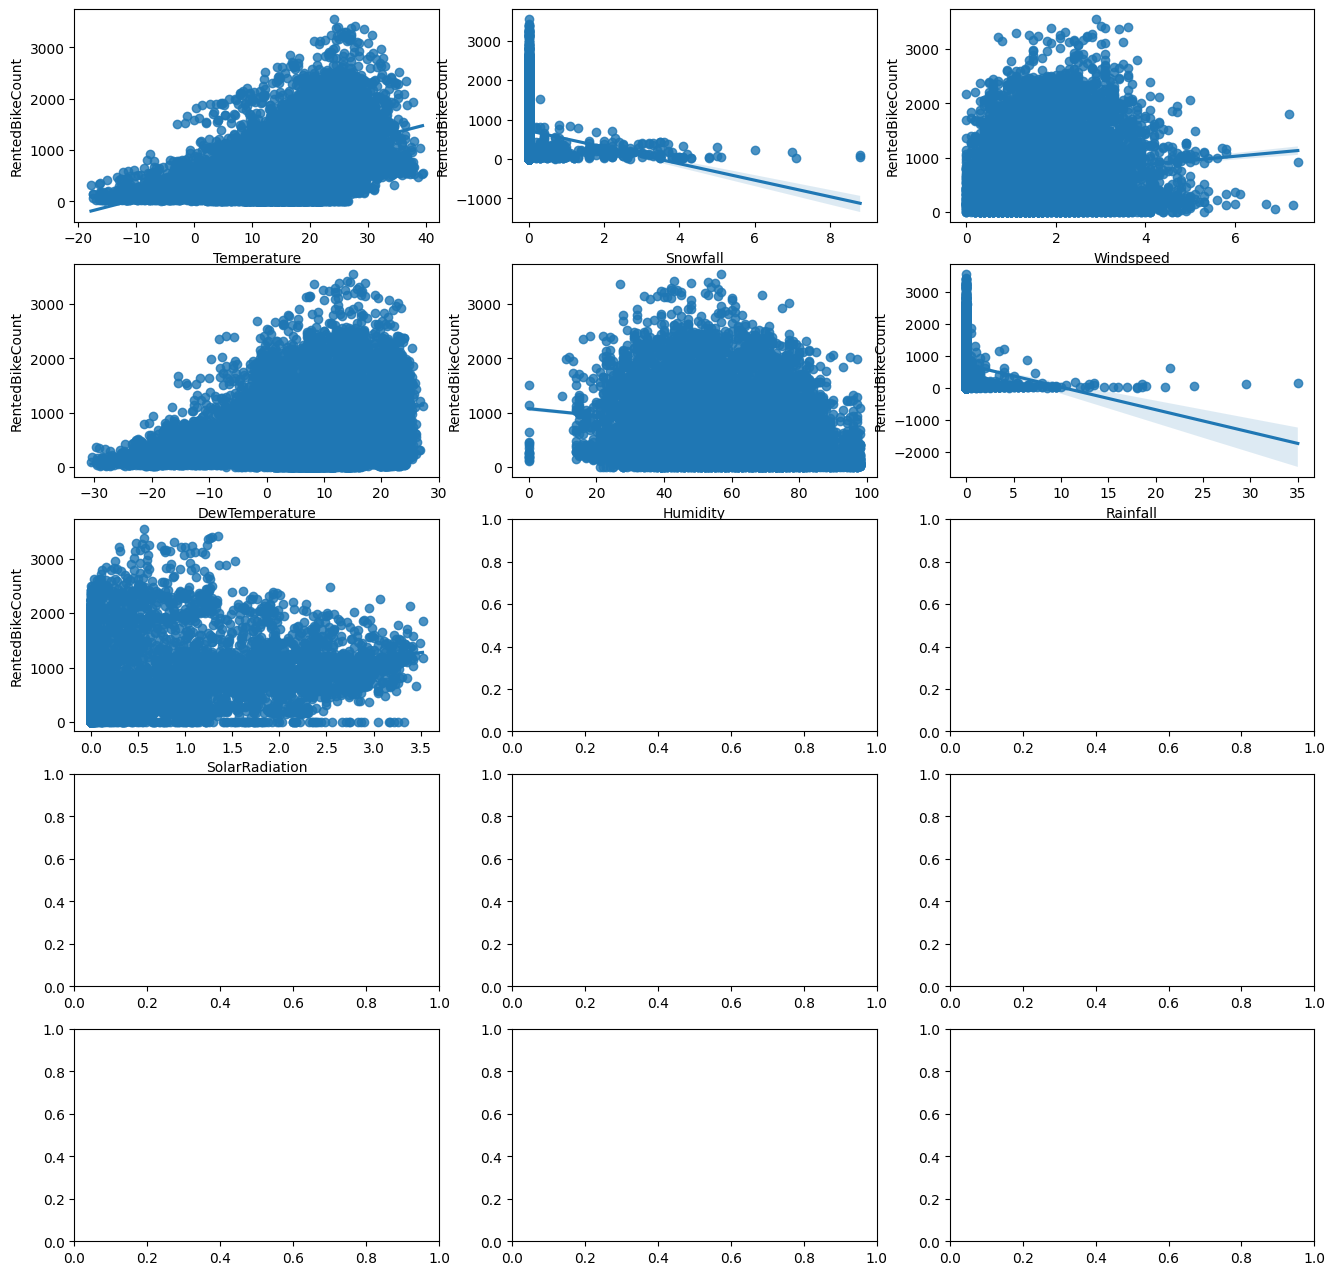

In [40]:
fig, axs = plt.subplots(figsize = (16, 16), ncols = 3, nrows = 5)

x_features = ['Temperature', 'Snowfall', 'Windspeed', 'DewTemperature', 'Humidity', 'Rainfall', 'SolarRadiation']

for i, feature in enumerate(x_features):
  row = int(i/3)
  col = i%3
  sns.regplot(x = feature, y = 'RentedBikeCount', data = bike_df, ax = axs[row][col])